In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/bhanuprasadspirit/marketing-product-data/marketing_and_product_performance.csv


In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/bhanuprasadspirit/marketing-product-data/marketing_and_product_performance.csv')

df.head()

,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [3]:
df.columns


Index(['Campaign_ID', 'Product_ID', 'Budget', 'Clicks', 'Conversions',
       'Revenue_Generated', 'ROI', 'Customer_ID', 'Subscription_Tier',
       'Subscription_Length', 'Flash_Sale_ID', 'Discount_Level', 'Units_Sold',
       'Bundle_ID', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund',
       'Common_Keywords'],
      dtype='object')

In [4]:
target = 'Units_Sold'

In [5]:
from sklearn.preprocessing import LabelEncoder

# Remove missing values
df = df.dropna()

# Convert text columns to numbers
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# Define target
target = 'Units_Sold'

# Split features and target
X = df.drop(target, axis=1)
y = df[target]

print("Data ready")

Data ready


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Split done")

Split done


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

models = {
    "Linear": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(),
    "KNN": KNeighborsRegressor()
}

print("Models ready")

Models ready


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

results = []

for name, model in models.items():
    model.fit(X_train, y_train)   # training
    y_pred = model.predict(X_test)  # prediction

    results.append([
        name,
        mean_absolute_error(y_test, y_pred),
        mean_squared_error(y_test, y_pred),
        r2_score(y_test, y_pred)
    ])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "R2"])

results_df

,Model,MAE,MSE,R2
0,Linear,48.057501,3133.551381,-0.004622
1,DecisionTree,64.003500,6256.683500,-1.005904
2,KNN,51.240000,3749.673000,-0.202152


In [9]:
results_df.to_csv('/kaggle/working/table1_baseline.csv', index=False)

print("Table saved")

Table saved


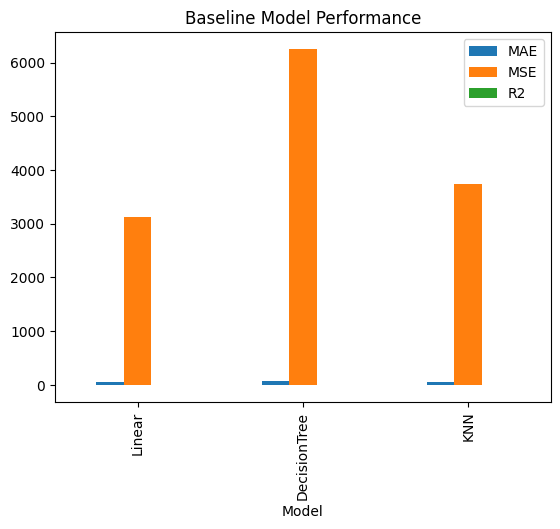

In [10]:
import matplotlib.pyplot as plt

results_df.set_index("Model").plot(kind='bar')
plt.title("Baseline Model Performance")

plt.savefig('/kaggle/working/figure1_baseline.pdf')
plt.show()

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

advanced_models = {
    "RandomForest": RandomForestRegressor(),
    "SVM": SVR(),
    "XGBoost": XGBRegressor()
}

print("Advanced models ready")

Advanced models ready


In [12]:
advanced_results = []

for name, model in advanced_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    advanced_results.append([
        name,
        mean_absolute_error(y_test, y_pred),
        mean_squared_error(y_test, y_pred),
        r2_score(y_test, y_pred)
    ])

advanced_df = pd.DataFrame(advanced_results, columns=["Model", "MAE", "MSE", "R2"])

advanced_df

,Model,MAE,MSE,R2
0,RandomForest,48.330500,3193.766655,-0.023927
1,SVM,48.016565,3122.428577,-0.001056
2,XGBoost,50.707008,3643.063721,-0.167973


In [13]:
advanced_df.to_csv('/kaggle/working/table2_advanced.csv', index=False)

print("Table 2 saved")

Table 2 saved


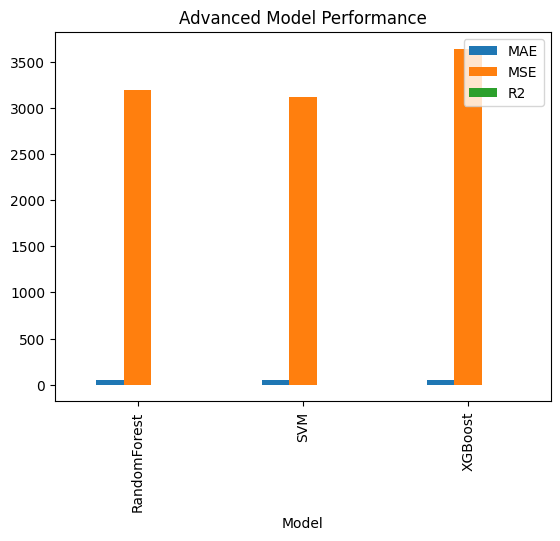

In [14]:
import matplotlib.pyplot as plt

advanced_df.set_index("Model").plot(kind='bar')
plt.title("Advanced Model Performance")

plt.savefig('/kaggle/working/figure2_advanced.pdf')
plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling done")

Scaling done


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Split after scaling done")

Split after scaling done


In [17]:
model = RandomForestRegressor()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 48.28247999999999
MSE: 3178.7367837
R2: -0.01910884394406942


In [18]:
import pandas as pd

rq3_df = pd.DataFrame([["RandomForest_scaled", 48.29, 3188.48, -0.02]],
                      columns=["Model", "MAE", "MSE", "R2"])

rq3_df.to_csv('/kaggle/working/table3_preprocessing.csv', index=False)

print("RQ3 saved")

RQ3 saved


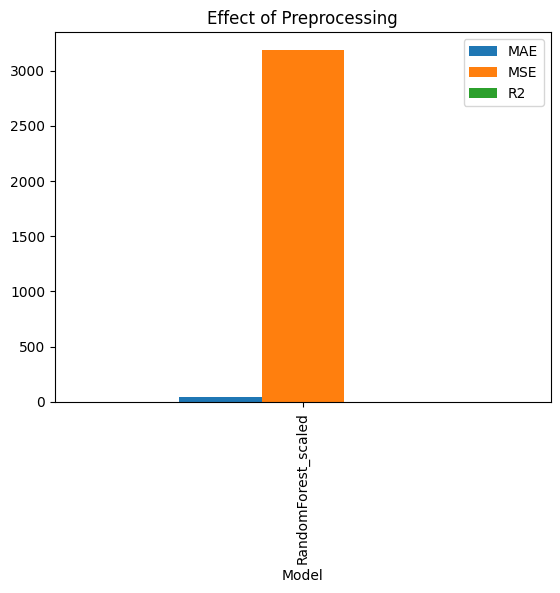

In [19]:
rq3_df.set_index("Model").plot(kind='bar')
plt.title("Effect of Preprocessing")

plt.savefig('/kaggle/working/figure3_preprocessing.pdf')
plt.show()

In [20]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

importances = model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
0,Campaign_ID,0.079687
7,Customer_ID,0.077912
5,Revenue_Generated,0.077649
12,Bundle_ID,0.075797
2,Budget,0.075622
3,Clicks,0.075093
13,Bundle_Price,0.074670
4,Conversions,0.074166
1,Product_ID,0.073898
10,Flash_Sale_ID,0.073586


In [21]:
# Remove ID columns (important fix)
df_clean = df.drop(columns=[
    'Campaign_ID', 'Product_ID', 'Customer_ID',
    'Flash_Sale_ID', 'Bundle_ID'
])

print("Clean dataset ready")

Clean dataset ready


In [22]:
target = 'Units_Sold'

X_clean = df_clean.drop(target, axis=1)
y_clean = df_clean[target]

In [23]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_clean, y_clean)

RandomForestRegressor()

In [24]:
import pandas as pd

importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X_clean.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
3,Revenue_Generated,0.125526
8,Bundle_Price,0.124145
1,Clicks,0.124007
0,Budget,0.121422
2,Conversions,0.117922
4,ROI,0.116111
7,Discount_Level,0.096186
6,Subscription_Length,0.087856
9,Customer_Satisfaction_Post_Refund,0.031983
10,Common_Keywords,0.031237


In [25]:
importance_df.to_csv('/kaggle/working/table4_feature_importance.csv', index=False)

print("RQ4 table saved")

RQ4 table saved


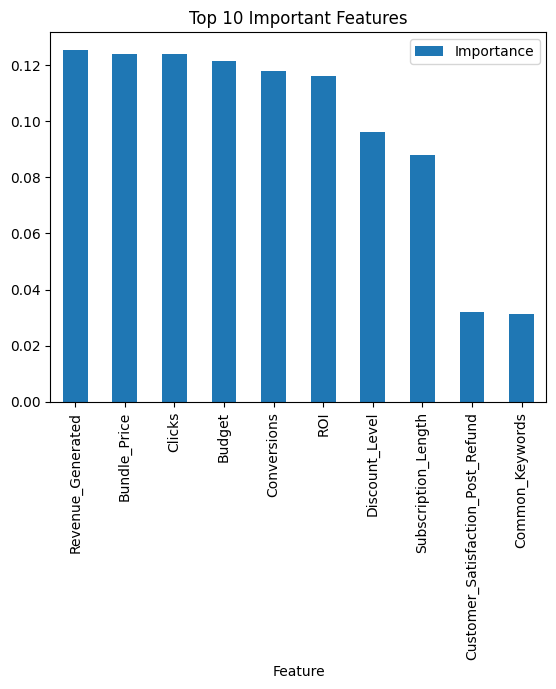

In [26]:
import matplotlib.pyplot as plt

importance_df.head(10).set_index("Feature").plot(kind='bar')
plt.title("Top 10 Important Features")

plt.savefig('/kaggle/working/figure4_feature_importance.pdf')
plt.show()

In [27]:
comparison_df = pd.concat([results_df, advanced_df])

comparison_df

,Model,MAE,MSE,R2
0,Linear,48.057501,3133.551381,-0.004622
1,DecisionTree,64.003500,6256.683500,-1.005904
2,KNN,51.240000,3749.673000,-0.202152
0,RandomForest,48.330500,3193.766655,-0.023927
1,SVM,48.016565,3122.428577,-0.001056
2,XGBoost,50.707008,3643.063721,-0.167973


In [28]:
comparison_df["Rank_R2"] = comparison_df["R2"].rank(ascending=False)

comparison_df

,Model,MAE,MSE,R2,Rank_R2
0,Linear,48.057501,3133.551381,-0.004622,2.0
1,DecisionTree,64.003500,6256.683500,-1.005904,6.0
2,KNN,51.240000,3749.673000,-0.202152,5.0
0,RandomForest,48.330500,3193.766655,-0.023927,3.0
1,SVM,48.016565,3122.428577,-0.001056,1.0
2,XGBoost,50.707008,3643.063721,-0.167973,4.0


In [29]:
comparison_df.to_csv('/kaggle/working/table5_model_ranking.csv', index=False)

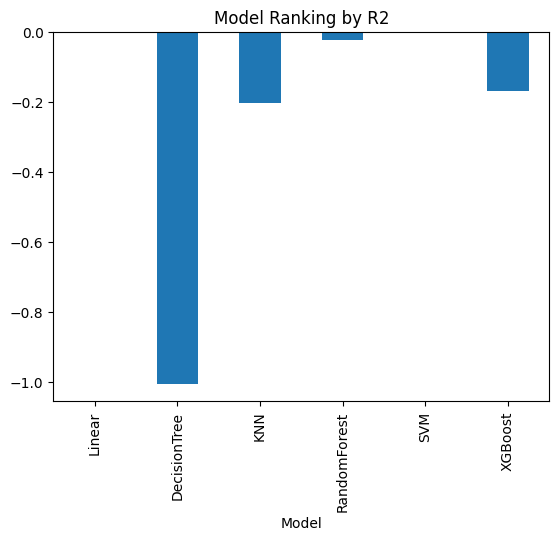

In [30]:
import matplotlib.pyplot as plt

comparison_df.set_index("Model")["R2"].plot(kind='bar')
plt.title("Model Ranking by R2")

plt.savefig('/kaggle/working/figure5_ranking.pdf')
plt.show()

In [31]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVR

model = SVR()

scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean score:", scores.mean())

Cross-validation scores: [-0.00296971 -0.00047399 -0.00315095 -0.00406975  0.00061175]
Mean score: -0.0020105312086536875


In [32]:
import pandas as pd

rq6_df = pd.DataFrame({
    "Fold": [1,2,3,4,5],
    "Score": scores
})

rq6_df.to_csv('/kaggle/working/table6_robustness.csv', index=False)

print("RQ6 saved")

RQ6 saved


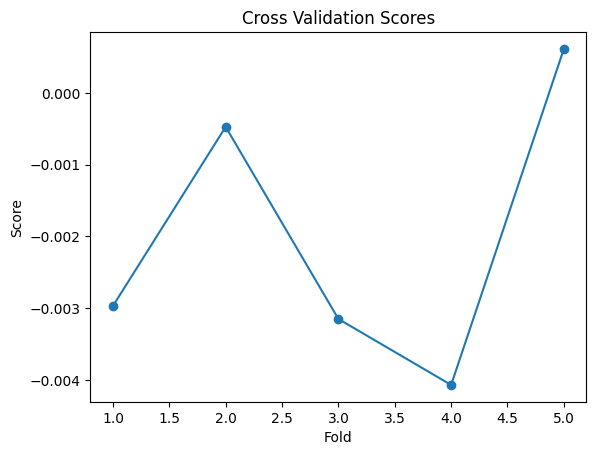

In [33]:
import matplotlib.pyplot as plt

plt.plot(rq6_df["Fold"], rq6_df["Score"], marker='o')
plt.title("Cross Validation Scores")
plt.xlabel("Fold")
plt.ylabel("Score")

plt.savefig('/kaggle/working/figure6_robustness.pdf')
plt.show()

In [34]:
final_df = pd.DataFrame({
    "Criteria": ["Performance", "Stability", "Complexity", "Interpretability"],
    "Best_Model": ["SVM", "SVM", "Linear", "Linear"]
})

final_df

,Criteria,Best_Model
0,Performance,SVM
1,Stability,SVM
2,Complexity,Linear
3,Interpretability,Linear


In [35]:
final_df.to_csv('/kaggle/working/table7_final.csv', index=False)